Gradient Boosting ek ensemble learning algorithm hai jisme bahut saare chhote Decision Trees milkar ek powerful model banate hain.

👉 Iska main idea hai:

Har naya tree pichle trees ki mistakes ko fix karta hai.

Yaad rakhne wali line:

"Previous tree ne jo galti ki, next tree usko sudharta hai."

# Example

Maan lo tum teacher ho aur 3 students ke marks predict karne hain.

Actual Marks:

| Student | Actual Marks |
| ------- | ------------ |
| A       | 90           |
| B       | 70           |
| C       | 100          |

# Step 1: First Tree

Pehla tree kuch simple prediction karta hai.

Suppose sabke liye predict kiya

80

| Student | Actual | Prediction |
| ------- | ------ | ---------- |
| A       | 90     | 80         |
| B       | 70     | 80         |
| C       | 100    | 80         |

Clearly prediction perfect nahi hai.

# Step 2: Errors (Residuals)

Ab dekhte hain kitni galti hui.

Residual = Actual − Prediction

| Student | Error |
| ------- | ----- |
| A       | +10   |
| B       | -10   |
| C       | +20   |


Ye errors batate hain ki model ne kaha mistake ki.

# Step 3: Second Tree

Ab doosra tree marks predict nahi karega.

Wo sirf errors ko predict karega.

Tree 2 bole:

A -> +8

B -> -9

C -> +18

Ye actual errors ke kaafi close hain.

# Step 4: Update Prediction
Ab final prediction banega

Old Prediction +
Learning Rate × New Prediction

Suppose Learning Rate = 0.1

Student A

Old Prediction

80

Correction

0.1 × 8 = 0.8

New Prediction

80.8

Ab prediction actual value (90) ke aur paas aa gaya.

# Step 5: Phir Error Nikalo

Ab naye prediction ke baad fir error niklega.

Example

90 - 80.8 = 9.2

Ab third tree isi 9.2 ko predict karega.

Fir prediction aur improve hogi.

Fir fourth tree.

Fir fifth tree.

...

Aise hi 100–500 trees ban sakte hain.

Har tree sirf bachi hui mistakes ko kam karta hai.

# Gradient Kaha Se Aaya?

Naam hai Gradient Boosting, sirf Residual Boosting nahi.

Reason:

Machine Learning me hum ek Loss Function ko minimize karte hain.

Example:

Loss = (Actual - Prediction)^2

Is loss ko kam karne ke liye Gradient Descent use hota hai.

Gradient batata hai:

Prediction ko kis direction me change karna hai taaki loss kam ho.

Gradient Boosting me har naya tree isi negative gradient ko predict karta hai.

Regression me:

Negative Gradient = Residual

Residual = Actual - Prediction

Isliye regression me log bol dete hain

Gradient Boosting residuals ko predict karta hai.

Lekin technically wo negative gradient predict karta hai.



# Learning Rate Kya Hai?
Learning Rate batata hai

Har tree ki baat kitni sunni hai.

Example

Tree correction

+20

Learning Rate

0.1

Final correction

20 × 0.1 = 2

Agar Learning Rate

1

To pura correction le lega.

Agar

0.01

To bahut chhota correction lega.

Isliye chhoti learning rate model ko stable banati hai, lekin zyada trees chahiye hote hain.

# Gradient Boosting vs Random Forest

| Random Forest                       | Gradient Boosting                                 |
| ----------------------------------- | ------------------------------------------------- |
| Har tree independent hota hai.      | Har tree previous tree ki mistake se seekhta hai. |
| Parallel training hoti hai.         | Sequential training hoti hai.                     |
| Bagging use karta hai.              | Boosting use karta hai.                           |
| Variance kam karta hai.             | Bias kam karta hai.                               |
| Fast train hota hai.                | Thoda slow hota hai.                              |
| Overfitting ka chance kam hota hai. | Agar tuning sahi na ho to overfit kar sakta hai.  |


# "Gradient Boosting ek sequential ensemble technique hai jisme har naya decision tree previous model ki mistakes (negative gradient/residuals) ko learn karke unhe correct karta hai, jisse overall prediction step-by-step improve hoti hai."

Random Forest:

Sab trees ek saath independently kaam karte hain aur voting/averaging se prediction dete hain.

Gradient Boosting:

Har naya tree pichle tree ki mistakes ko thoda-thoda improve karta hai, aur sabhi trees milkar final prediction banate hain.

 # Code

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
np.random.seed(42)
X = np.random.rand(100, 1) - 0.5
y = 3*X[:, 0]**2 + 0.05 * np.random.randn(100)



In [ ]:
import pandas as pd

In [ ]:

df = pd.DataFrame()

In [ ]:

df['X'] = X.reshape(100)
df['y'] = y


In [ ]:
df

,X,y
0,-0.125460,0.051573
1,0.450714,0.594480
2,0.231994,0.166052
3,0.098658,-0.070178
4,-0.343981,0.343986
...,...,...
95,-0.006204,-0.040675
96,0.022733,-0.002305
97,-0.072459,0.032809
98,-0.474581,0.689516


Text(0.5, 1.0, 'X vs Y')

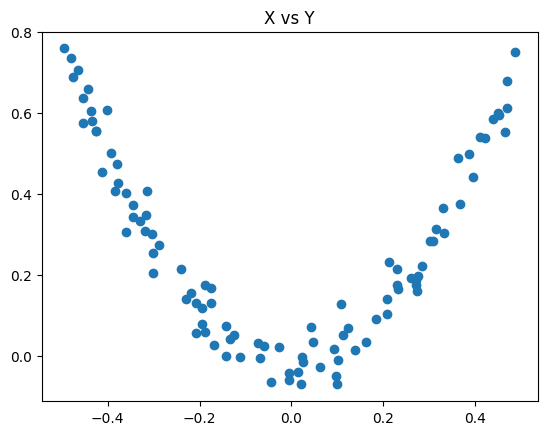

In [ ]:
plt.scatter(df['X'],df['y'])
plt.title('X vs Y')

In [ ]:
df['pred1'] = df['y'].mean()

In [ ]:
df

,X,y,pred1
0,-0.125460,0.051573,0.265458
1,0.450714,0.594480,0.265458
2,0.231994,0.166052,0.265458
3,0.098658,-0.070178,0.265458
4,-0.343981,0.343986,0.265458
...,...,...,...
95,-0.006204,-0.040675,0.265458
96,0.022733,-0.002305,0.265458
97,-0.072459,0.032809,0.265458
98,-0.474581,0.689516,0.265458


In [ ]:
df['res1'] = df['y'] - df['pred1']

In [ ]:
df

,X,y,pred1,res1
0,-0.125460,0.051573,0.265458,-0.213885
1,0.450714,0.594480,0.265458,0.329021
2,0.231994,0.166052,0.265458,-0.099407
3,0.098658,-0.070178,0.265458,-0.335636
4,-0.343981,0.343986,0.265458,0.078528
...,...,...,...,...
95,-0.006204,-0.040675,0.265458,-0.306133
96,0.022733,-0.002305,0.265458,-0.267763
97,-0.072459,0.032809,0.265458,-0.232650
98,-0.474581,0.689516,0.265458,0.424057


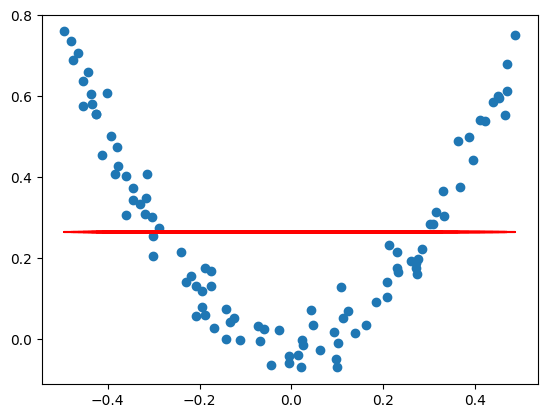

In [ ]:
plt.scatter(df['X'],df['y'])
plt.plot(df['X'],df['pred1'],color='red')

In [ ]:
from sklearn.tree import DecisionTreeRegressor

In [ ]:
tree1 = DecisionTreeRegressor(max_leaf_nodes=8)

In [ ]:
tree1.fit(df['X'].values.reshape(100,1),df['res1'].values)

DecisionTreeRegressor(max_leaf_nodes=8)

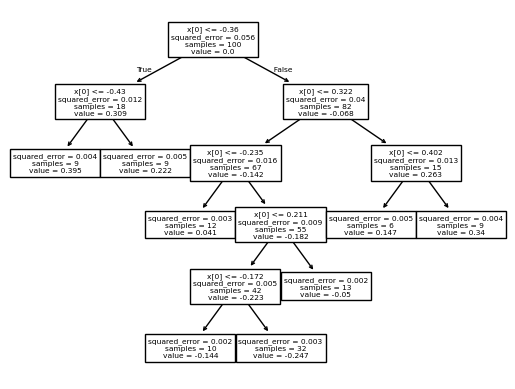

In [ ]:
from sklearn.tree import plot_tree
plot_tree(tree1)
plt.show()

In [ ]:
# generating X_test
X_test = np.linspace(-0.5, 0.5, 500)

In [ ]:

y_pred = 0.265458 + tree1.predict(X_test.reshape(500, 1))

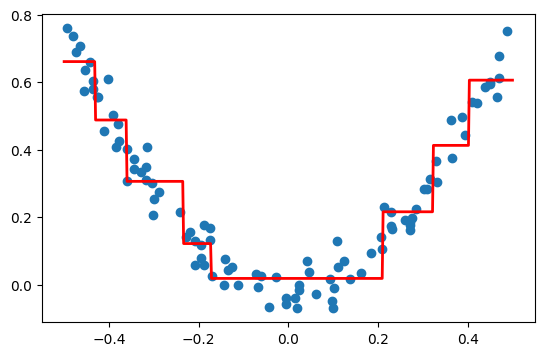

In [ ]:
plt.figure(figsize=(14,4))
plt.subplot(121)
plt.plot(X_test, y_pred, linewidth=2,color='red')
plt.scatter(df['X'],df['y'])


In [ ]:
df['pred2'] = 0.265458 + tree1.predict(df['X'].values.reshape(100,1))

In [ ]:
df

,X,y,pred1,res1,pred2
0,-0.125460,0.051573,0.265458,-0.213885,0.018319
1,0.450714,0.594480,0.265458,0.329021,0.605884
2,0.231994,0.166052,0.265458,-0.099407,0.215784
3,0.098658,-0.070178,0.265458,-0.335636,0.018319
4,-0.343981,0.343986,0.265458,0.078528,0.305964
...,...,...,...,...,...
95,-0.006204,-0.040675,0.265458,-0.306133,0.018319
96,0.022733,-0.002305,0.265458,-0.267763,0.018319
97,-0.072459,0.032809,0.265458,-0.232650,0.018319
98,-0.474581,0.689516,0.265458,0.424057,0.660912


In [ ]:
df['res2'] = df['y'] - df['pred2']

In [ ]:
df

,X,y,pred1,res1,pred2,res2
0,-0.125460,0.051573,0.265458,-0.213885,0.018319,0.033254
1,0.450714,0.594480,0.265458,0.329021,0.605884,-0.011404
2,0.231994,0.166052,0.265458,-0.099407,0.215784,-0.049732
3,0.098658,-0.070178,0.265458,-0.335636,0.018319,-0.088497
4,-0.343981,0.343986,0.265458,0.078528,0.305964,0.038022
...,...,...,...,...,...,...
95,-0.006204,-0.040675,0.265458,-0.306133,0.018319,-0.058994
96,0.022733,-0.002305,0.265458,-0.267763,0.018319,-0.020624
97,-0.072459,0.032809,0.265458,-0.232650,0.018319,0.014489
98,-0.474581,0.689516,0.265458,0.424057,0.660912,0.028604


In [ ]:
tree2 = DecisionTreeRegressor(max_leaf_nodes=8)

In [ ]:
tree2.fit(df['X'].values.reshape(100,1),df['res2'].values)

DecisionTreeRegressor(max_leaf_nodes=8)

In [ ]:
y_pred = 0.265458 + sum(regressor.predict(X_test.reshape(-1, 1)) for regressor in [tree1,tree2])

Text(0.5, 1.0, 'X vs y')

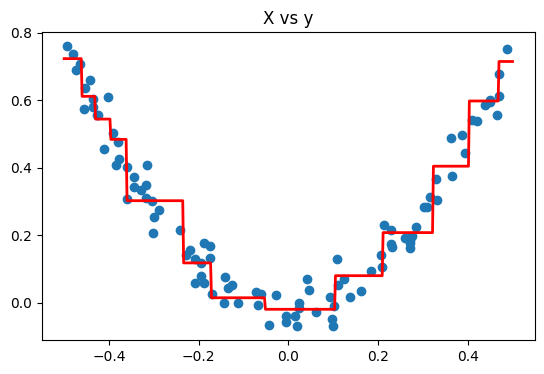

In [ ]:
plt.figure(figsize=(14,4))
plt.subplot(121)
plt.plot(X_test, y_pred, linewidth=2,color='red')
plt.scatter(df['X'],df['y'])
plt.title('X vs y')


In [ ]:
def gradient_boost(X,y,number,lr,count=1,regs=[],foo=None):

  if number == 0:
    return
  else:
    # do gradient boosting

    if count > 1:
      y = y - regs[-1].predict(X)
    else:
      foo = y

    tree_reg = DecisionTreeRegressor(max_depth=5, random_state=42)
    tree_reg.fit(X, y)

    regs.append(tree_reg)

    x1 = np.linspace(-0.5, 0.5, 500)
    y_pred = sum(lr * regressor.predict(x1.reshape(-1, 1)) for regressor in regs)

    print(number)
    plt.figure()
    plt.plot(x1, y_pred, linewidth=2)
    plt.plot(X[:, 0], foo,"r.")
    plt.show()

    gradient_boost(X,y,number-1,lr,count+1,regs,foo=foo)


5


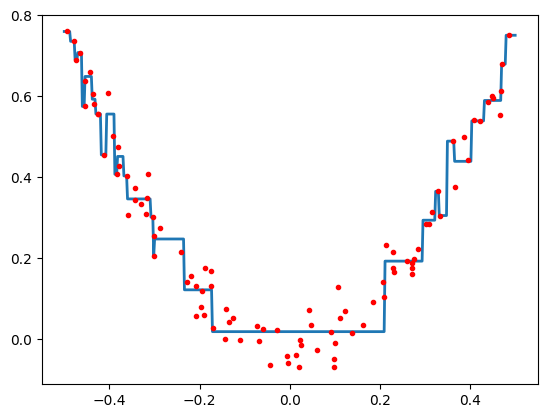

4


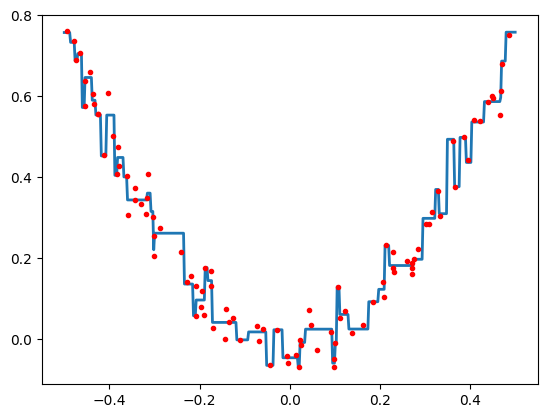

3


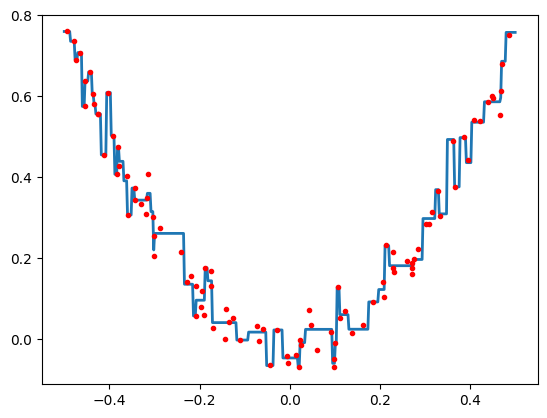

2


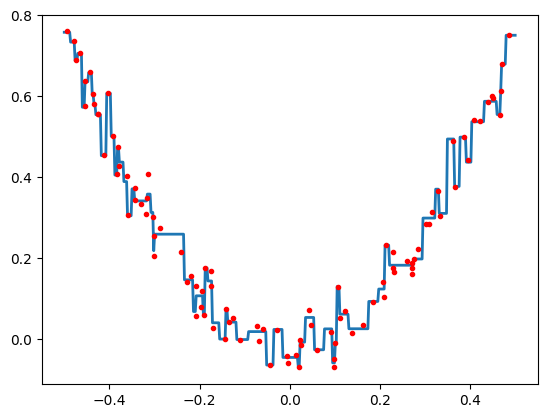

1


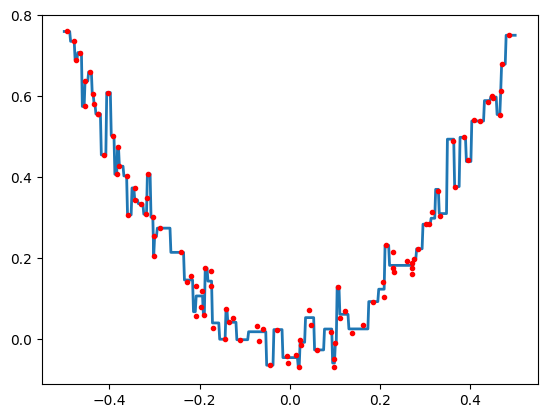

In [ ]:
np.random.seed(42)
X = np.random.rand(100, 1) - 0.5
y = 3*X[:, 0]**2 + 0.05 * np.random.randn(100)
gradient_boost(X,y,5,lr=1)

# Additive Modelling

Additive modeling is a machine learning approach where the final prediction is built by adding the contributions of multiple simple models one after another.

# Simple Idea

Imagine you are trying to improve a drawing.

First, you draw a rough sketch.

Then you add more details.

Then you fix mistakes.

Then you add shading.

The final drawing is the sum of all these improvements.

Similarly, in additive modeling:

Final Prediction =
Model 1
+ Model 2
+ Model 3
+ ...
+ Model N

Each new model adds something to improve the previous prediction.

```
Formula
F(x)=f1(x)+f2(x)+f3(x)+⋯+fn(x)

where:

F(x) = Final prediction
fi(x) = Small model (usually a decision tree)

# Example

Suppose the true house price is ₹50 lakh.

Step 1

First model predicts:

40 lakh

Error:

50 - 40 = 10 lakh

Step 2

Second model learns this error.

It predicts:

+7 lakh

New prediction:

40 + 7 = 47 lakh

Remaining error:

50 - 47 = 3 lakh

Step 3

Third model predicts:

+2 lakh

New prediction:

47 + 2 = 49 lakh

Step 4

Fourth model predicts:

+1 lakh

Final prediction:

49 + 1 = 50 lakh

Notice that each model only corrects the mistakes of the previous models.

# Why is it called "Additive"?

Because every new model is added to the previous prediction.

Prediction = Previous Prediction + New Model

Not replaced—added.

# Mathematics behind Gradient Boosting

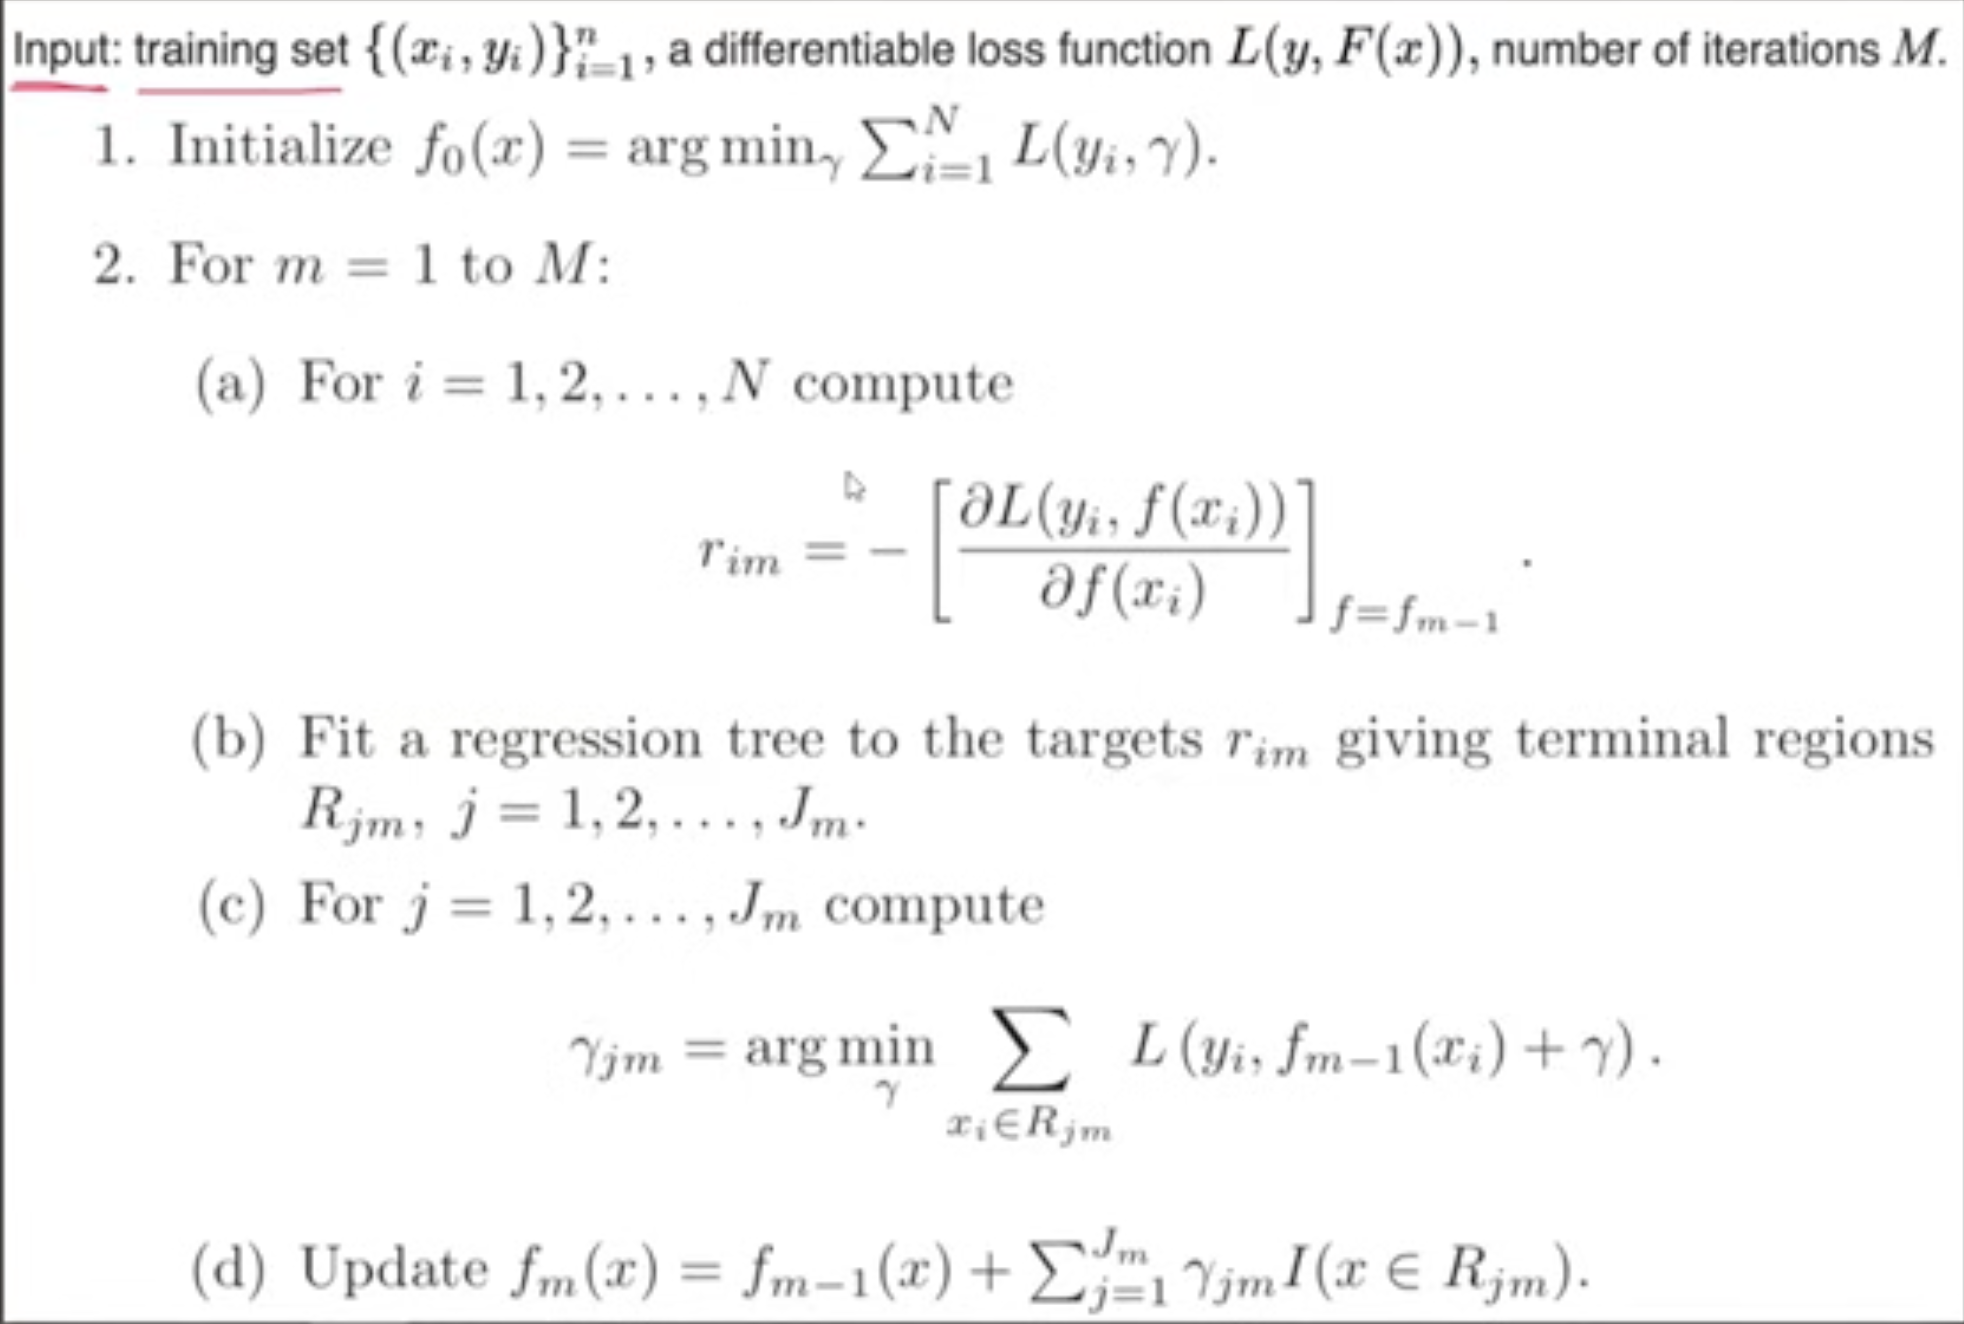

```
╔══════════════════════════════════════════════════════════════════════╗
║                    ADDITIVE MODELING (MATHEMATICS)                  ║
╚══════════════════════════════════════════════════════════════════════╝

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

📦 Step 1: We want to learn a function

Suppose our dataset is

+-----+-----+
|  x  |  y  |
+-----+-----+
|  1  |  3  |
|  2  |  5  |
|  3  |  7  |
+-----+-----+

We want a function

    F(x) ≈ y

where F(x) is our prediction.

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

📦 Step 2: Start with a simple model

Instead of building a huge model immediately, we start with

    F₀(x)

Suppose it predicts the average of all targets.

    F₀(x) = 5

Predictions become

+--------+------------+
| Actual | Prediction |
+--------+------------+
|   3    |     5      |
|   5    |     5      |
|   7    |     5      |
+--------+------------+

Clearly, there are errors.

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

📦 Step 3: Compute the error (Residual)

Residual is

    rᵢ = yᵢ − F₀(xᵢ)

Residual table

+--------+------------+----------+
| Actual | Prediction | Residual |
+--------+------------+----------+
|   3    |     5      |   -2     |
|   5    |     5      |    0     |
|   7    |     5      |    2     |
+--------+------------+----------+

Residual tells us how much the current model is wrong.

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

📦 Step 4: Train a new model on the residuals

Train another model

    f₁(x)

whose job is

    f₁(x) ≈ r

It learns only the mistakes of the first model.

Example predictions

+-----+----------------------+
|  x  | Residual Prediction  |
+-----+----------------------+
|  1  |        -1.8          |
|  2  |         0            |
|  3  |         1.9          |
+-----+----------------------+

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

📦 Step 5: Add it to the previous model

Update the model

    F₁(x) = F₀(x) + f₁(x)

Notice:

Old Model
    +
Correction Model
    =
Better Model

We ADD the new model.
We DO NOT replace the old model.

This is why it is called Additive Modeling.

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

📦 Step 6: Repeat

Compute new residuals

    r = y − F₁(x)

Train another model

    f₂(x)

Update

    F₂(x) = F₁(x) + f₂(x)

Again

    F₃(x) = F₂(x) + f₃(x)

Continue until

    Fₘ(x) = Fₘ₋₁(x) + fₘ(x)

Eventually

    Fₘ(x)
    = F₀(x)
    + f₁(x)
    + f₂(x)
    + ...
    + fₘ(x)

This is the mathematical definition of Additive Modeling.

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

📦 Why does adding models reduce the error?

Suppose the true function is

    y = f(x)

Current model

    F(x)

Current error

    e(x) = f(x) − F(x)

Suppose the next model learns

    f₁(x) ≈ e(x)

Now update

    F_new(x)
    = F(x) + f₁(x)

Substitute

    f₁(x) ≈ f(x) − F(x)

Then

    F_new(x)
    = F(x) + (f(x) − F(x))
    = f(x)

Hence,

The new model becomes much closer to the true function.

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

📦 Where does Gradient Boosting come in?

Instead of directly fitting

    Residual = y − F(x)

Gradient Boosting fits the Negative Gradient of the loss.

    rᵢ = − ∂L(y, F(x)) / ∂F(x)

Reason:

We want to minimize the loss function.

The negative gradient points in the direction that decreases the loss
the fastest.

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

📦 Example: Mean Squared Error (MSE)

Loss function

          1
    L = ----- (y − F(x))²
          2

Differentiate with respect to F(x)

    ∂L/∂F(x) = F(x) − y

Negative Gradient

    −∂L/∂F(x)
    = y − F(x)

This is exactly the residual.

Therefore,

    Residual = Negative Gradient

This is why Gradient Boosting fits residuals.

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

📦 Final Mathematical Equation

After M iterations

                  M
    Fₘ(x) = F₀(x) + Σ η fₘ(x)
                 m=1

where

F₀(x) = Initial prediction
fₘ(x) = Weak learner (small decision tree)
η      = Learning rate
M      = Number of boosting iterations

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

⭐ Core Idea

    New Model
    =
    Old Model
    +
    Small Correction

Repeatedly adding small corrections eventually produces a highly
accurate model.

```

# The key mathematical idea

At every iteration, we update the model as

New Model=Old Model+Small Correction
	​


Each correction is chosen to reduce the loss as much as possible. Over many iterations, these small corrections accumulate into a highly accurate model. This simple update rule is the mathematical foundation of additive modeling and the basis of algorithms like Gradient Boosting, XGBoost, LightGBM, and CatBoost.